In [6]:
import numpy as np
from sim_library.constants import k_eff, dR, m, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare
from sim_library.data_io import load_p_dists

In [7]:
def evolve_free(dt: float, state_vec: np.ndarray, delta_D: float, delta_R: float, delta_L: float, basis: np.ndarray):
    new_state_vec = np.zeros_like(state_vec)
    for i, n in enumerate(basis):
        if n % 2 == 0:
            new_state_vec[i] = state_vec[i]*np.exp(1j*n*(delta_D+(n*delta_R))*dt)
        else:
            new_state_vec[i] = state_vec[i]*np.exp(1j*(n*(delta_D+(n*delta_R))-delta_L)*dt)

In [8]:
def evolve_uppulse(dt: float, state_vec: np.ndarray, omega_R: float, phi_L: float, delta_D: float, delta_R: float, delta_L: float, basis: np.ndarray):
    new_state_vec = np.zeros_like(state_vec)
    start = 0
    end = len(basis)-1
    if basis[0] % 2 == 1:
        new_state_vec[0] = state_vec[0]*np.exp(1j*(basis[0]*(delta_D+(basis[0]*delta_R))-delta_L)*dt)
        start = 1
    if basis[-1] % 2 == 0:
        new_state_vec[-1] = state_vec[-1]*np.exp(1j*(basis[-1]*(delta_D+(basis[-1]*delta_R)))*dt)
    for i in range(start,end,2):
        n = basis[i]
        delta_p = delta_D + (2*n+1)*delta_R - delta_L
        omega_eff = np.sqrt((omega_R**2)+(delta_p**2))
        P = np.exp(1j*(n*(delta_D+(n*delta_R))+(delta_p/2))*dt)
        C = np.cos(omega_eff*dt/2)-(1j*(delta_p/omega_eff)*np.sin(omega_eff*dt/2))
        C_conj = np.cos(omega_eff*dt/2)+(1j*(delta_p/omega_eff)*np.sin(omega_eff*dt/2))
        S = np.exp(1j*phi_L)*(omega_R/omega_eff)*np.sin(omega_eff*dt/2)
        S_conj = np.exp(-1j*phi_L)*(omega_R/omega_eff)*np.sin(omega_eff*dt/2)
        new_state_vec[i] = P*((C*state_vec[i])-(1j*S_conj*state_vec[i+1]))
        new_state_vec[i+1] = P*((C_conj*state_vec[i+1])-(1j*S*state_vec[i]))

    return new_state_vec


    

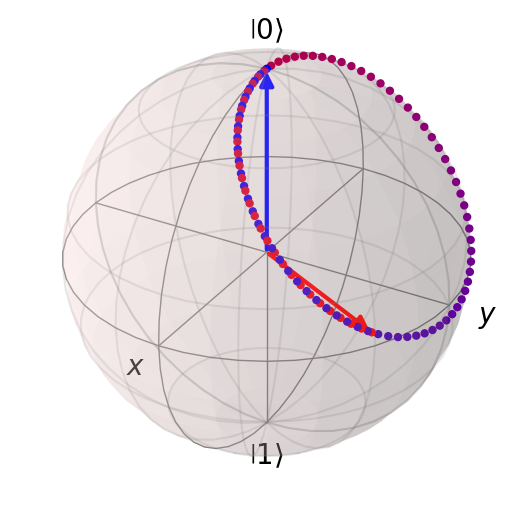

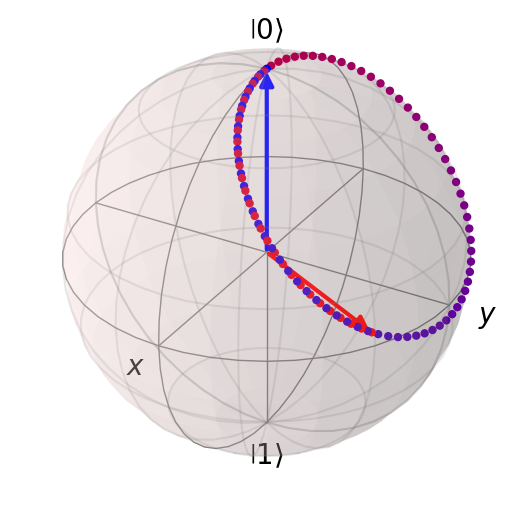

In [21]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*1e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 100
duration = rabi_time
dt = duration/(n_steps-1) # n_steps includes initial state

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -2
p_max = 2
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[2] = 1
initial_state[3] = 0
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0 # Stationary

wave_func = np.zeros((n_steps+1, len(basis)), dtype=np.complex128)
wave_func[0,:] = initial_state

for i in range(n_steps):
    wave_func[i+1,:] = evolve_uppulse(dt=dt, state_vec=wave_func[i,:], omega_R=rabi_freq, phi_L=pi/2, delta_D=k_eff*atom_veloc, delta_R=dR, delta_L=-5*dR, basis=basis)

plot_bloch(wave_func=wave_func[:,2:4])
